In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import os

# Your exact Drive path
file_path = '/content/drive/MyDrive/Projects for CV/Customer_Segmentation_Project/online_retail_II.csv'

if os.path.exists(file_path):
    print("Loading dataset instantly from your Google Drive...")
    df = pd.read_csv(file_path, parse_dates=['InvoiceDate'])
else:
    print("Downloading dataset from UCI... (This may takes 1 to 2 minutes)")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
    df = pd.read_excel(url)

    print("Saving to Google Drive as a CSV for fast loading next time...")
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    df.to_csv(file_path, index=False)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Raw Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

Saving to Google Drive as a CSV for fast loading next time...
Raw Dataset Shape: (525461, 8)

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [4]:
df_clean = df.dropna(subset=['Customer ID']).copy()

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['Price']

print(f"Cleaned Dataset Shape: {df_clean.shape}")

Cleaned Dataset Shape: (407664, 9)


In [7]:
import datetime as dt

latest_date = df_clean['InvoiceDate'].max()
snapshot_date = latest_date + dt.timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalSpend': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

display(rfm.head())
print(f"RFM Dataset Shape: {rfm.shape}")

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


RFM Dataset Shape: (4312, 3)


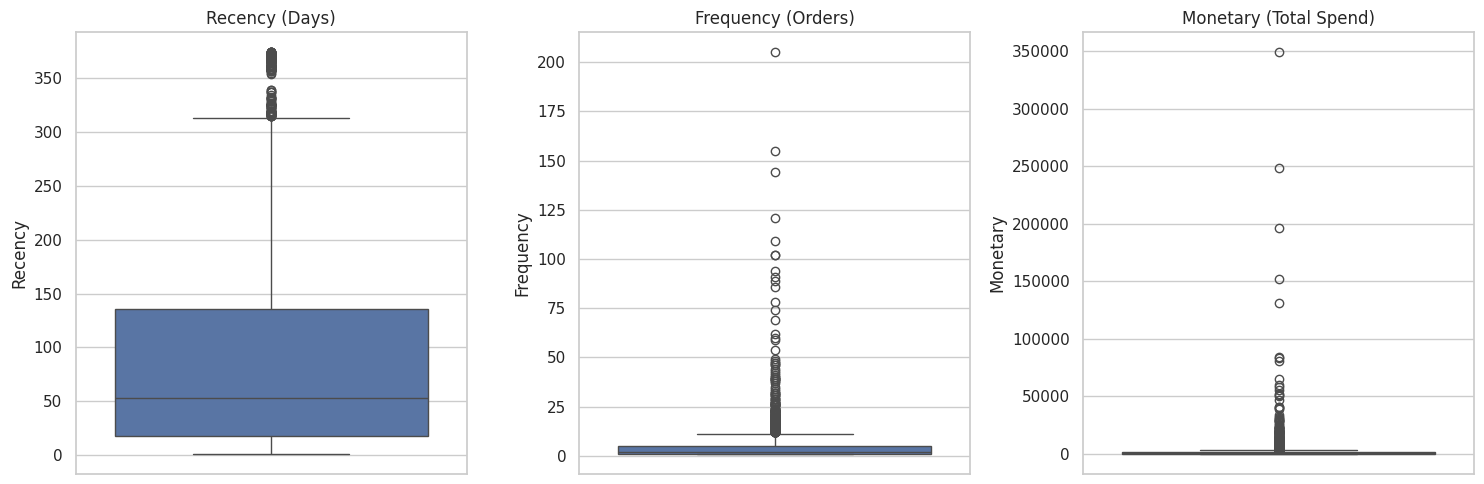


Top 5 Customers by Total Spend:


,Recency,Frequency,Monetary
Customer ID,,,
18102.0,1,89,349164.35
14646.0,10,78,248396.50
14156.0,7,102,196566.74
14911.0,1,205,152147.57
13694.0,9,94,131443.19


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for our graphs
sns.set_theme(style="whitegrid")

# Create a figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the distribution of Recency, Frequency, and Monetary scores
sns.boxplot(y=rfm['Recency'], ax=axes[0]).set_title('Recency (Days)')
sns.boxplot(y=rfm['Frequency'], ax=axes[1]).set_title('Frequency (Orders)')
sns.boxplot(y=rfm['Monetary'], ax=axes[2]).set_title('Monetary (Total Spend)')

plt.tight_layout()
plt.show()

# Show the exact numbers of our highest spenders
print("\nTop 5 Customers by Total Spend:")
display(rfm.sort_values(by='Monetary', ascending=False).head())

In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Log Transformation: Compress the extreme outliers
rfm_log = np.log(rfm + 1)

# 2. Standardization: Force everything onto the same scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Convert back to a Pandas DataFrame for readability
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("Data after Log Transformation and Scaling:")
display(rfm_scaled_df.head())

Data after Log Transformation and Scaling:


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.966262,1.613017,-0.540688
12347.0,-1.900165,-0.394693,0.447651
12348.0,0.355000,-0.981910,-0.943904
12349.0,-0.055302,0.021945,0.996204
12351.0,-1.054928,-0.981910,-0.707671


In [10]:
from sklearn.cluster import KMeans

# 1. Set up the algorithm to find exactly 3 distinct customer groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Train the algorithm on our perfectly scaled data
kmeans.fit(rfm_scaled_df)

# 3. Attach the algorithm's answers back to our ORIGINAL, readable RFM table
rfm['Cluster'] = kmeans.labels_

print("Original RFM Data with new Machine Learning Clusters:")
display(rfm.head(10))

Original RFM Data with new Machine Learning Clusters:


,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,0
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,2
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0
12352.0,11,2,343.80,0
12353.0,44,1,317.76,2
12355.0,203,1,488.21,2
12356.0,16,3,3562.25,0


In [11]:
# Group the original RFM table by our new clusters and calculate the averages
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'] # 'count' tells us how many customers are in the group
}).round(1)

print("Business Profile of Each Customer Segment:")
display(cluster_summary)

Business Profile of Each Customer Segment:


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          54.4       3.4   1300.1  1763
1          17.9      13.4   7360.2   812
2         162.8       1.3    324.4  1737

In [13]:
# 1. Create the rulebook
def assign_segment(cluster_number):
    if cluster_number == 1:
        return 'VIP Customers'
    elif cluster_number == 0:
        return 'Average Customers'
    else:
        return 'At-Risk Customers'

# 2. Apply it to create the missing 'Segment' column
rfm['Segment'] = rfm['Cluster'].apply(assign_segment)

print("Segment column successfully added!")
display(rfm.head())

Segment column successfully added!


,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,0,Average Customers
12347.0,3,2,1323.32,0,Average Customers
12348.0,74,1,222.16,2,At-Risk Customers
12349.0,43,3,2671.14,0,Average Customers
12351.0,11,1,300.93,0,Average Customers


In [14]:
import plotly.express as px

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Segment',
    title='Interactive 3D Customer Segmentation Map',
    opacity=0.7,
    color_discrete_sequence=['#ef553b', '#00cc96', '#636efa'] # Red, Green, Blue
)

# Update layout to make it look clean
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Display the graph
fig.show()

In [28]:
import pandas as pd
import numpy as np

print("--- Interactive Customer Segment Predictor ---")

r_input = float(input("Enter Days Since Last Purchase (Recency): "))
f_input = float(input("Enter Number of Orders (Frequency): "))
m_input = float(input("Enter Total Spend in Dollars (Monetary): "))

new_customer = pd.DataFrame({
    'Recency': [r_input],
    'Frequency': [f_input],
    'Monetary': [m_input]
})

new_log = np.log(new_customer + 1)
new_scaled = scaler.transform(new_log)

new_scaled_df = pd.DataFrame(new_scaled, columns=new_customer.columns)

# Make the prediction using the named DataFrame
predicted_cluster = kmeans.predict(new_scaled_df)[0]
predicted_segment = assign_segment(predicted_cluster)

print(f"\n>>> AI Prediction: This user belongs to the '{predicted_segment}' group! <<<")

--- Interactive Customer Segment Predictor ---
Enter Days Since Last Purchase (Recency): 3
Enter Number of Orders (Frequency): 2
Enter Total Spend in Dollars (Monetary): 4500

>>> AI Prediction: This user belongs to the 'VIP Customers' group! <<<
